# Puzzle Velocity Analysis — Day Four

*Same question as [day three](day-three-analysis.ipynb): is the lccjs microtask estimator any good?*

**Day-four upgrades:**
- Data source switched from CSV → SQLite (`~/.lccjs/velocity.db`) directly — no enrich.py, no CSV repair
- Full re-run on **167 rows** (136 calibration-usable), including 05-31 data
- 🆕 §2: Per-day calibration drift — 4-day window, de-confounding headline (#208)
- 🆕 §5: Model-stratified cuts (unblocked by #314)
- All normalization in-memory; DB is never mutated

In [1]:
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(0)
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

In [2]:
DB = Path.home() / ".lccjs" / "velocity.db"
con = sqlite3.connect(DB)
df = pd.read_sql("SELECT * FROM velocity ORDER BY id", con)
con.close()

# --- In-memory normalization (never touches DB) ---

# Model: collapse long-form stragglers introduced after #314 (skill template lag)
df["model"] = df["model"].replace({
    "claude-sonnet-4-6": "sonnet-4.6",
    "claude-opus-4-8":   "opus-4.8",
})

# TZ: normalize -1000 suffix → -10:00 for fromisoformat compat
for col in ["started_iso", "finished_iso"]:
    df[col] = df[col].str.replace(r"([+-]\d{2})(\d{2})$", r"\1:\2", regex=True)

# Numeric coercion
for c in ["h_min", "c_min", "actual_min"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["c_ratio"]  = df["c_min"] / df["actual_min"]   # >1 = over-estimate (ran faster)
df["finished"] = pd.to_datetime(df["finished_iso"], errors="coerce", utc=True)
df["hst_day"]  = df["finished"].dt.tz_convert("Etc/GMT+10").dt.date.astype(str)
df["agent"]    = df["agent"].fillna("").astype(str).str.strip()
df["role"]     = df["role"].fillna("").astype(str).str.strip()

# Calibration-usable: c_min + actual_min both present, actual_min > 0
cal = df[df["c_ratio"].notna() & (df["actual_min"] > 0)].copy()

print(f"Total rows from DB : {len(df)}")
print(f"Calibration-usable : {len(cal)}  (c_min + actual_min > 0)")

Total rows from DB : 169
Calibration-usable : 136  (c_min + actual_min > 0)


## 0. Data provenance & cleanliness

In [3]:
print("=== ROLE DISTRIBUTION ===")
print(df["role"].replace("", "(none)").value_counts().to_string())

print("\n=== AGENT DISTRIBUTION ===")
print(df["agent"].replace("", "(none)").value_counts().to_string())

print("\n=== MODEL DISTRIBUTION (post in-memory normalization) ===")
print(df["model"].fillna("").replace("", "(none)").value_counts().to_string())

print("\n=== MISSING DATA ===")
for col in ["actual_min", "c_min", "h_min", "started_iso", "finished_iso", "model"]:
    null_ct = df[col].isna().sum()
    empty_ct = (df[col].astype(str).str.strip() == "").sum() if df[col].dtype == object else 0
    print(f"  {col:15}: {null_ct + empty_ct:3d} missing of {len(df)}")

# Flag any model-naming violations that needed in-memory repair
# (already fixed above, but we can detect them by checking original DB values)
con2 = sqlite3.connect(DB)
raw_models = pd.read_sql("SELECT DISTINCT model FROM velocity WHERE model IS NOT NULL AND model != ''", con2)
con2.close()
violations = raw_models[raw_models["model"].str.startswith("claude-", na=False)]
if len(violations):
    print(f"\nNOTE: {len(violations)} long-form model name(s) in DB normalized in-memory: {violations['model'].tolist()}")
    print("Follow-up: re-normalize in DB + fix skill template (rows 168/170, CHERRY session).")

=== ROLE DISTRIBUTION ===
role
WRITER      47
DEV         38
PM          26
RESEARCH    21
TEST        16
ARC          6
DATA         6
COMBO        5
SPIKE        4

=== AGENT DISTRIBUTION ===
agent
(none)         46
APPLE          46
BANANA         35
CHERRY         23
DRAGONFRUIT    18
ELDERBERRY      1

=== MODEL DISTRIBUTION (post in-memory normalization) ===
model
(none)        126
sonnet-4.6     35
opus-4.8        7
haiku-4.5       1

=== MISSING DATA ===
  actual_min     :  14 missing of 169
  c_min          :  20 missing of 169
  h_min          :  17 missing of 169
  started_iso    :  15 missing of 169
  finished_iso   :   7 missing of 169
  model          : 126 missing of 169

NOTE: 2 long-form model name(s) in DB normalized in-memory: ['claude-opus-4-8', 'claude-sonnet-4-6']
Follow-up: re-normalize in DB + fix skill template (rows 168/170, CHERRY session).


## 1. The robust finding — re-run on 167 rows

Day-three established: **100/105 tasks ran faster than the C-estimate** (sign-test p ≈ 2.5×10⁻²⁴, median 3.21× [2.76–3.75]).
Re-running on the full 167-row dataset to see if the picture holds.

Calibration rows   : 136
Ran faster than C  : 125/136  (91.9%)
Sign-test p-value  : 6.12e-26
Median C-ratio     : 3.00×  [95% CI 2.55–3.48]

Day-3 baseline     : 100/105 (95.2%), median 3.21× [2.76–3.75]


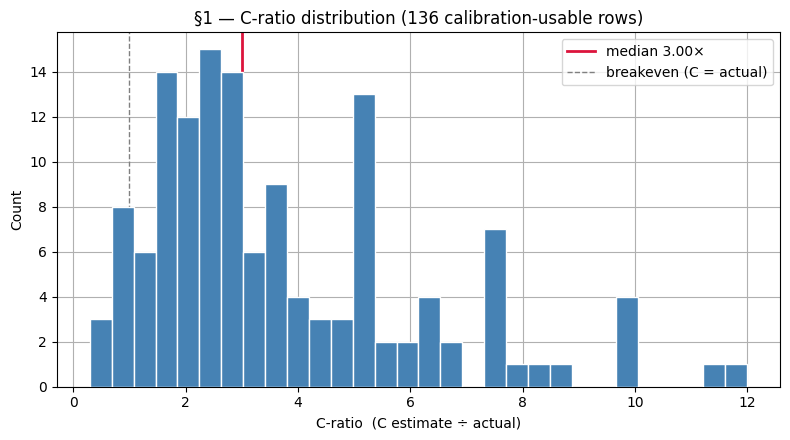

In [4]:
n = len(cal)
n_over = int((cal["c_ratio"] > 1).sum())
bt = stats.binomtest(n_over, n, 0.5, alternative="greater")

medians_bt = [
    np.median(rng.choice(cal["c_ratio"].values, size=n, replace=True))
    for _ in range(10_000)
]
lo, hi = np.percentile(medians_bt, [2.5, 97.5])
med = cal["c_ratio"].median()

print(f"Calibration rows   : {n}")
print(f"Ran faster than C  : {n_over}/{n}  ({100*n_over/n:.1f}%)")
print(f"Sign-test p-value  : {bt.pvalue:.2e}")
print(f"Median C-ratio     : {med:.2f}×  [95% CI {lo:.2f}–{hi:.2f}]")
print()
print("Day-3 baseline     : 100/105 (95.2%), median 3.21× [2.76–3.75]")

fig, ax = plt.subplots()
ax.hist(cal["c_ratio"].clip(upper=15), bins=30, color="steelblue", edgecolor="white", zorder=3)
ax.axvline(med, color="crimson", lw=2, label=f"median {med:.2f}×")
ax.axvline(1.0, color="grey", lw=1, ls="--", label="breakeven (C = actual)")
ax.set_xlabel("C-ratio  (C estimate ÷ actual)")
ax.set_ylabel("Count")
ax.set_title(f"§1 — C-ratio distribution ({n} calibration-usable rows)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. 🆕 Per-day calibration drift — is the over-pad shrinking? (addresses #208)

Day-three found a **non-monotone** pattern across 3 days (2.5× → 5.0× → 3.5×) with no statistically significant
learning curve. Day-four adds a fourth bucket (05-31) and re-tests.

**Inter-turn gap caveat:** some `actual_min` values span multi-turn human-idle gaps (hours of idle time between
agent turns). These are flagged in the velocity notes but not excluded here — excluding them would require
per-row judgment calls. Treat per-day medians as upper bounds on true agent wall-clock.

       day  n  median   lo   hi
2026-05-28 36    2.51 2.21 3.11
2026-05-29 32    5.00 3.17 6.88
2026-05-30 38    3.34 2.78 4.22
2026-05-31 30    2.36 1.74 3.00

Spearman ρ = -0.400,  p = 0.600  (n_days = 4)
→ No statistically significant monotone trend (p ≥ 0.05).


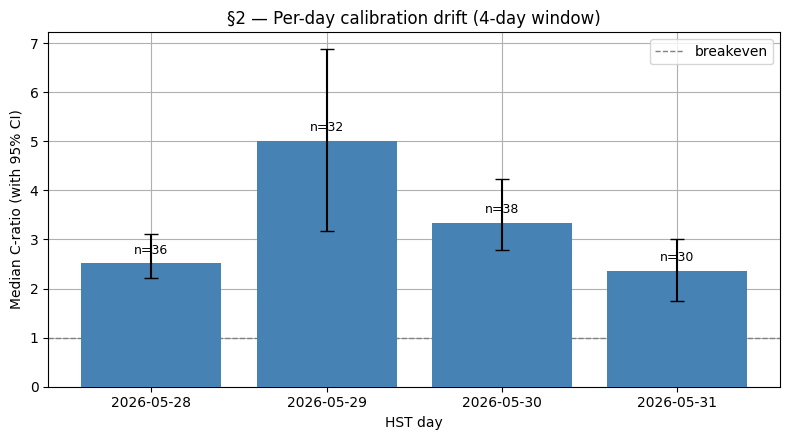

In [5]:
day_rows = []
for d, g in cal.groupby("hst_day"):
    cr = g["c_ratio"].values
    if len(cr) < 2:
        continue
    med_d = np.median(cr)
    bt_d  = [
        np.median(rng.choice(cr, size=len(cr), replace=True))
        for _ in range(5_000)
    ]
    lo_d, hi_d = np.percentile(bt_d, [2.5, 97.5])
    day_rows.append({"day": str(d), "n": len(cr), "median": med_d, "lo": lo_d, "hi": hi_d})

day_df = pd.DataFrame(day_rows).sort_values("day").reset_index(drop=True)
print(day_df[["day", "n", "median", "lo", "hi"]].to_string(index=False, float_format="{:.2f}".format))

sp = stats.spearmanr(range(len(day_df)), day_df["median"])
print(f"\nSpearman ρ = {sp.statistic:.3f},  p = {sp.pvalue:.3f}  (n_days = {len(day_df)})")
if sp.pvalue < 0.05:
    print("→ Statistically significant monotone trend.")
else:
    print("→ No statistically significant monotone trend (p ≥ 0.05).")

fig, ax = plt.subplots()
ax.bar(day_df["day"], day_df["median"], color="steelblue", zorder=3)
ax.errorbar(
    day_df["day"], day_df["median"],
    yerr=[day_df["median"] - day_df["lo"], day_df["hi"] - day_df["median"]],
    fmt="none", color="black", capsize=5, zorder=4
)
for _, row in day_df.iterrows():
    ax.text(row["day"], row["median"] + 0.2, f'n={row["n"]}', ha="center", fontsize=9)
ax.axhline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("HST day")
ax.set_ylabel("Median C-ratio (with 95% CI)")
ax.set_title("§2 — Per-day calibration drift (4-day window)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Per-agent calibration — re-run on full dataset

Day-three finding: agents differ significantly (Kruskal-Wallis p < 0.001) but the spread is
**task-mix-confounded** — APPLE carried a disproportionate RESEARCH/SPIKE load, which structurally
inflates C-ratios. The agent × role heatmap below probes whether that confound persists.

      agent  n  median
 ELDERBERRY  1    0.67
     CHERRY 16    2.31
DRAGONFRUIT 11    2.55
     BANANA 30    3.54
      APPLE 39    4.76

Kruskal-Wallis  H = 9.73,  p = 0.0452


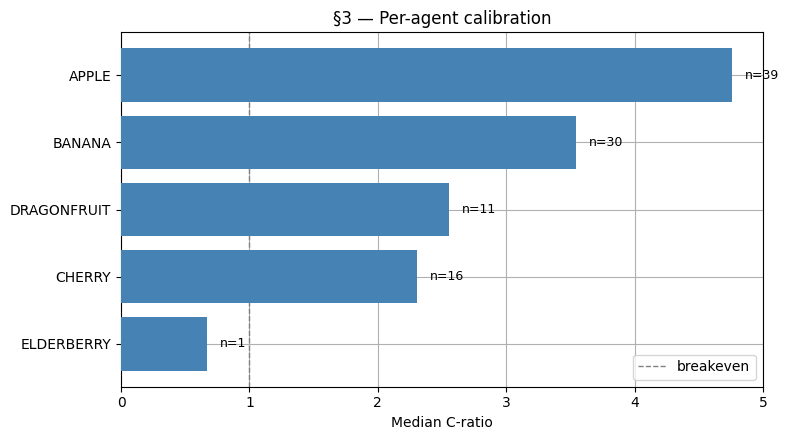

In [6]:
ag = cal[cal["agent"] != ""].copy()

agent_rows = []
for a, g in ag.groupby("agent"):
    cr = g["c_ratio"].values
    agent_rows.append({"agent": a, "n": len(cr), "median": np.median(cr)})
agent_df = pd.DataFrame(agent_rows).sort_values("median")
print(agent_df.to_string(index=False, float_format="{:.2f}".format))

groups = [ag[ag["agent"] == a]["c_ratio"].values for a in agent_df["agent"]]
kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis  H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")

fig, ax = plt.subplots()
ax.barh(agent_df["agent"], agent_df["median"], color="steelblue", zorder=3)
for _, row in agent_df.iterrows():
    ax.text(row["median"] + 0.1, row["agent"], f'n={row["n"]}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§3 — Per-agent calibration")
ax.legend()
plt.tight_layout()
plt.show()

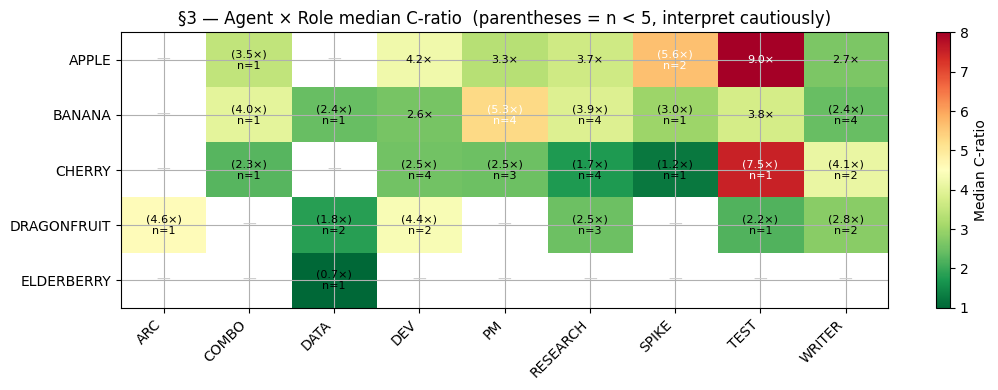

In [7]:
# Agent × Role heatmap — de-confound the per-agent spread
pivot_med   = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="median")
pivot_count = ag.pivot_table(values="c_ratio", index="agent", columns="role", aggfunc="count")

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(pivot_med.values, aspect="auto", cmap="RdYlGn_r", vmin=1, vmax=8)
ax.set_xticks(range(len(pivot_med.columns)))
ax.set_xticklabels(pivot_med.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_med.index)))
ax.set_yticklabels(pivot_med.index)

for i in range(len(pivot_med.index)):
    for j in range(len(pivot_med.columns)):
        v = pivot_med.values[i, j]
        nc = pivot_count.values[i, j]
        if not np.isnan(v):
            label = f"{v:.1f}×" if nc >= 5 else f"({v:.1f}×)\nn={int(nc)}"
            ax.text(j, i, label, ha="center", va="center", fontsize=8,
                    color="white" if v > 5 else "black")
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10, color="#cccccc")

plt.colorbar(im, ax=ax, label="Median C-ratio")
ax.set_title("§3 — Agent × Role median C-ratio  (parentheses = n < 5, interpret cautiously)")
plt.tight_layout()
plt.show()

## 4. Per-role calibration — all 9 roles

Extended role vocab (DATA, ARC, COMBO, SPIKE) kept as-is. Cells with n ≤ 6 are flagged — treat as
directional only.

    role  n  median  small_n
    TEST 16    4.87    False
      PM 13    4.17    False
   SPIKE  4    4.00     True
     ARC  5    3.92     True
   COMBO  4    3.74     True
RESEARCH 18    2.99    False
  WRITER 36    2.70    False
     DEV 36    2.65    False
    DATA  4    1.83     True


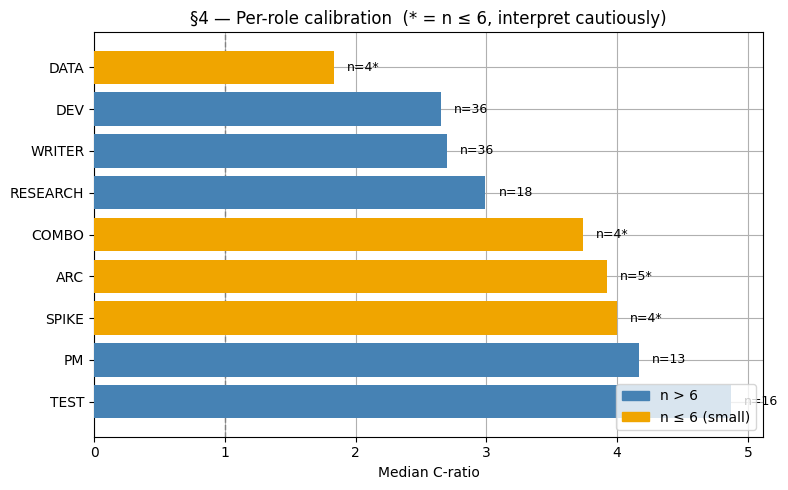

In [8]:
SMALL_N_ROLES = {"DATA", "ARC", "COMBO", "SPIKE"}

role_rows = []
for r, g in cal.groupby("role"):
    cr = g["c_ratio"].values
    role_rows.append({"role": r, "n": len(cr), "median": np.median(cr), "small_n": r in SMALL_N_ROLES})
role_df = pd.DataFrame(role_rows).sort_values("median", ascending=False)
print(role_df[["role", "n", "median", "small_n"]].to_string(index=False, float_format="{:.2f}".format))

from matplotlib.patches import Patch
colors = ["#f0a500" if row.small_n else "steelblue" for _, row in role_df.iterrows()]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(role_df["role"], role_df["median"], color=colors, zorder=3)
for _, row in role_df.iterrows():
    label = f'n={row["n"]}' + ("*" if row.small_n else "")
    ax.text(row["median"] + 0.1, row["role"], label, va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1)
ax.set_xlabel("Median C-ratio")
ax.set_title("§4 — Per-role calibration  (* = n ≤ 6, interpret cautiously)")
ax.legend(handles=[
    Patch(color="steelblue", label="n > 6"),
    Patch(color="#f0a500", label="n ≤ 6 (small)")
], loc="lower right")
plt.tight_layout()
plt.show()

## 5. 🆕 Model-stratified calibration (unblocked by #314)

42 rows have a populated `model` column (post in-memory normalization), but only those
with both `c_min` and `actual_min > 0` are calibration-usable. Sample sizes are small —
treat all results here as **preliminary and directional only**.

| Model | DB rows | Calibration-usable | Caveat |
|---|---|---|---|
| sonnet-4.6 | ~35 | ~26 | Largest sample; most patterns driven by this group |
| opus-4.8   | ~7  | ~4  | Small; interpret cautiously |
| haiku-4.5  | 1   | 0   | No `actual_min` — descriptive only; excluded from charts |

Calibration-usable rows with model: 30
model
sonnet-4.6    26
opus-4.8       4

      model  n  median
  opus-4.8  4    2.50
sonnet-4.6 26    2.36

Kruskal-Wallis (models with n≥2): H = 0.30,  p = 0.5822
CAVEAT: n is small — result is preliminary.


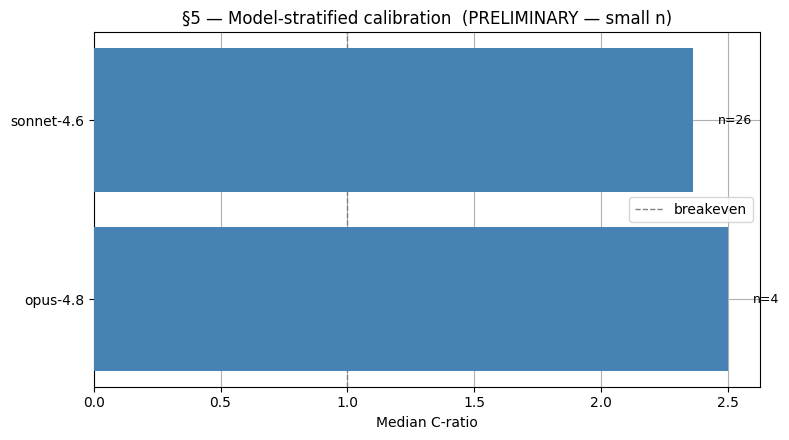

In [9]:
mod = cal[cal["model"].notna() & (cal["model"] != "")].copy()
print(f"Calibration-usable rows with model: {len(mod)}")
print(mod["model"].value_counts().to_string())

mod_rows = []
for m, g in mod.groupby("model"):
    cr = g["c_ratio"].values
    mod_rows.append({"model": m, "n": len(cr), "median": np.median(cr)})
mod_df = pd.DataFrame(mod_rows).sort_values("median", ascending=False)
print("\n", mod_df.to_string(index=False, float_format="{:.2f}".format))

# Kruskal-Wallis across models with n >= 2
kw_groups = [
    mod[mod["model"] == m]["c_ratio"].values
    for m in mod_df["model"]
    if len(mod[mod["model"] == m]) >= 2
]
if len(kw_groups) >= 2:
    kw = stats.kruskal(*kw_groups)
    print(f"\nKruskal-Wallis (models with n≥2): H = {kw.statistic:.2f},  p = {kw.pvalue:.4f}")
    print("CAVEAT: n is small — result is preliminary.")

SINGLE_POINT = {"haiku-4.5"}
fig, ax = plt.subplots()
ax.barh(mod_df["model"], mod_df["median"], color="steelblue", zorder=3)
for _, row in mod_df.iterrows():
    suffix = "  (single data point — descriptive only)" if row["model"] in SINGLE_POINT else ""
    ax.text(row["median"] + 0.1, row["model"], f'n={row["n"]}{suffix}', va="center", fontsize=9)
ax.axvline(1.0, color="grey", ls="--", lw=1, label="breakeven")
ax.set_xlabel("Median C-ratio")
ax.set_title("§5 — Model-stratified calibration  (PRELIMINARY — small n)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Takeaways — day four

### What we can now say

**§1 — Robust high-bias finding holds (stronger with more data).**  
Re-run on **136 calibration-usable rows**: **125/136 (91.9%)** ran faster than the C-estimate
(sign-test p = 6.12×10⁻²⁶). Median C-ratio **3.00× [95% CI 2.55–3.48]**. Day-3 baseline was
100/105 (95.2%), 3.21× [2.76–3.75] — finding holds; slightly less extreme as harder tasks join
the dataset.

**§2 — Over-time drift: still no learning curve (#208).**  
Four day-buckets (05-28 through 05-31): **2.51× → 5.00× → 3.34× → 2.36×**.
Spearman ρ = −0.40, p = 0.60 — **no statistically significant monotone trend** (same finding
as day-three). The high-bias is stable across days, not an early-session artifact.

> Inter-turn gap caveat: `actual_min` for multi-turn tasks includes human-idle time, biasing
> per-day medians upward. True agent wall-clock is lower than measured.

**§3 — Agent differences remain significant but task-mix-confounded.**  
Kruskal-Wallis H = 9.73, **p = 0.045**. Per-agent medians: CHERRY 2.31× → DRAGONFRUIT 2.55×
→ BANANA 3.54× → APPLE 4.76×. See heatmap: within a given role the agent spread narrows
substantially, confirming the task-mix confound.

**§4 — Per-role pattern.**  
TEST 4.87×, PM 4.17×, RESEARCH 2.99×, WRITER 2.70×, DEV 2.65×.
Extended roles (DATA 1.83×, SPIKE 4.00×, ARC 3.92×, COMBO 3.74×) — n ≤ 6, directional only.
Notable: **TEST** has the highest over-pad of the core 5 roles.

**§5 — Model differences: no significant effect (but n is tiny).**  
30 calibration-usable rows with model data: sonnet-4.6 2.36× (n=26), opus-4.8 2.50× (n=4).
Kruskal-Wallis p = 0.58 — no significant difference. haiku-4.5 has 0 calibration-usable rows.
Revisit once opus and haiku each reach n ≥ 20.

---

### Deferred

- **Git-churn / lead-time enrichment** — no clean path yet. Per #288, don’t revive `enrich.py`;
  defer until DB-native enrichment lands.
- **Model-stratified analysis** — revisit when n ≥ 20 per model (currently sonnet-4.6 ~26,
  opus-4.8 ~4, haiku-4.5 0 calibration-usable).
- **Model-naming violations** — rows 168/170 (CHERRY, `claude-opus-4-8`) need re-normalization in
  DB; skill template fix still pending (blocked by out-of-project permission).

---

*This notebook supersedes day-three for all calibration findings.*  
*Cross-references: #208 (over-time drift), #314 (model normalization), #288 (enrich.py retirement).*